<a href="https://colab.research.google.com/github/iammishrasatyam/Tweet-Tracker-Sentiment-Analysis/blob/main/Tweet_Tracker_Budget2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tweet Tracker – Budget 2025 Sentiment Analysis
**Dataset:** `budget_2025_dummy_tweets.csv` (500 tweets)

---
## Project Overview
This notebook contain 4-Steps:
- **Step 1** – Setup & Data Loading
- **Step 2** – Data Cleaning & Preprocessing
- **Step 3** – Sentiment Analysis (TextBlob + VADER)
- **Step 4** – Visualization & Insights

---
# Step 1 – Setup & Data Loading

In [73]:
# Install required libraries (run once)
!pip install textblob vaderSentiment wordcloud --quiet
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
# Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


In [76]:
#  Upload the dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('budget_2025_dummy_tweets.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Saving budget_2025_dummy_tweets.csv to budget_2025_dummy_tweets (4).csv
Dataset shape: (500, 5)
Columns: ['Date', 'Tweet_ID', 'Username', 'Content', 'URL']


,Date,Tweet_ID,Username,Content,URL
0,2025-02-23,2097783610944,@taxbuster,Loved the emphasis on clean energy and sustain...,https://twitter.com/taxbuster/status/209778361...
1,2025-03-16,5492368699879,@startupbuddy,"Too much focus on startups, not enough for agr...",https://twitter.com/startupbuddy/status/549236...
2,2025-02-18,5392074834536,@commonman123,More allocation to healthcare is a welcome move.,https://twitter.com/commonman123/status/539207...
3,2025-03-08,3928156117274,@bharatfirst,"This is a budget for the rich, not the middle ...",https://twitter.com/bharatfirst/status/3928156...
4,2025-03-03,9122345186066,@aamjanta,"Too much focus on startups, not enough for agr...",https://twitter.com/aamjanta/status/9122345186066
5,2025-04-08,4758428974200,@taxbuster,MSME sector got a boost. Hope it helps local b...,https://twitter.com/taxbuster/status/475842897...
6,2025-03-12,1944798434173,@indiapolitics,Where is the support for the salaried class?,https://twitter.com/indiapolitics/status/19447...
7,2025-03-02,4139103461776,@indiapolitics,More allocation to healthcare is a welcome move.,https://twitter.com/indiapolitics/status/41391...
8,2025-03-20,1031243835810,@bharatfirst,Disappointed with no tax relief in this year’s...,https://twitter.com/bharatfirst/status/1031243...
9,2025-03-29,6221803854317,@bharatfirst,MSME sector got a boost. Hope it helps local b...,https://twitter.com/bharatfirst/status/6221803...


In [77]:
# Basic exploration
print("  Dataset Info  ")
print(df.info())
print()
print("  Missing Values  ")
print(df.isnull().sum())
print()
print("  Sample Tweets  ")
for i, row in df.head(5).iterrows():
    print(f"[{row['Username']}] {row['Content'][:100]}")

  Dataset Info  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      500 non-null    object
 1   Tweet_ID  500 non-null    int64 
 2   Username  500 non-null    object
 3   Content   500 non-null    object
 4   URL       500 non-null    object
dtypes: int64(1), object(4)
memory usage: 19.7+ KB
None

  Missing Values  
Date        0
Tweet_ID    0
Username    0
Content     0
URL         0
dtype: int64

  Sample Tweets  
[@taxbuster] Loved the emphasis on clean energy and sustainability!
[@startupbuddy] Too much focus on startups, not enough for agriculture.
[@commonman123] More allocation to healthcare is a welcome move.
[@bharatfirst] This is a budget for the rich, not the middle class.
[@aamjanta] Too much focus on startups, not enough for agriculture.


---
#  Step 2 – Data Cleaning & Preprocessing

In [78]:
# Cleaning function
def clean_tweet(tweet):
    """Clean a single tweet string."""
    if not isinstance(tweet, str):
        return ""
    tweet = tweet.lower()                              # lowercase
    tweet = re.sub(r"http\S+|www\S+|https\S+", "", tweet)  # remove URLs
    tweet = re.sub(r"@\w+", "", tweet)                # remove @mentions
    tweet = re.sub(r"#", "", tweet)                   # remove # symbol (keep hashtag text)
    tweet = re.sub(r"[^\w\s]", "", tweet)             # remove punctuation
    tweet = re.sub(r"\d+", "", tweet)                 # remove digits
    tweet = re.sub(r"\s+", " ", tweet).strip()        # collapse whitespace
    return tweet

# Apply cleaning
df['clean_text'] = df['Content'].apply(clean_tweet)

# Drop rows where clean_text is empty after cleaning
df = df[df['clean_text'].str.len() > 0].copy()

print(f"Rows after cleaning: {len(df)}")
df[['Content', 'clean_text']].head(5)

Rows after cleaning: 500


,Content,clean_text
0,Loved the emphasis on clean energy and sustain...,loved the emphasis on clean energy and sustain...
1,"Too much focus on startups, not enough for agr...",too much focus on startups not enough for agri...
2,More allocation to healthcare is a welcome move.,more allocation to healthcare is a welcome move
3,"This is a budget for the rich, not the middle ...",this is a budget for the rich not the middle c...
4,"Too much focus on startups, not enough for agr...",too much focus on startups not enough for agri...


In [79]:
#  Stopword removal & tokenization (optional but useful)
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    return " ".join([w for w in tokens if w not in stop_words])

df['clean_text_no_stop'] = df['clean_text'].apply(remove_stopwords)

# Tweet length and word count features
df['char_count']  = df['clean_text'].str.len()
df['word_count']  = df['clean_text'].str.split().map(len)

print("Average tweet length (chars):", round(df['char_count'].mean(), 1))
print("Average word count           :", round(df['word_count'].mean(), 1))
df[['Content', 'clean_text', 'char_count', 'word_count']].head()

Average tweet length (chars): 50.3
Average word count           : 8.6


,Content,clean_text,char_count,word_count
0,Loved the emphasis on clean energy and sustain...,loved the emphasis on clean energy and sustain...,53,8
1,"Too much focus on startups, not enough for agr...",too much focus on startups not enough for agri...,53,9
2,More allocation to healthcare is a welcome move.,more allocation to healthcare is a welcome move,47,8
3,"This is a budget for the rich, not the middle ...",this is a budget for the rich not the middle c...,50,11
4,"Too much focus on startups, not enough for agr...",too much focus on startups not enough for agri...,53,9


---
# Step 3 – Sentiment Analysis (TextBlob + VADER)

In [80]:
#  TextBlob sentiment
def textblob_score(text):
    return TextBlob(text).sentiment.polarity

def textblob_label(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_score'] = df['clean_text'].apply(textblob_score)
df['textblob_label'] = df['textblob_score'].apply(textblob_label)

print("TextBlob distribution:")
print(df['textblob_label'].value_counts())

TextBlob distribution:
textblob_label
Positive    285
Neutral     158
Negative     57
Name: count, dtype: int64


In [81]:
#  VADER sentiment
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    return analyzer.polarity_scores(text)['compound']

def vader_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_score'] = df['clean_text'].apply(vader_score)
df['vader_label'] = df['vader_score'].apply(vader_label)

print("VADER distribution:")
print(df['vader_label'].value_counts())

VADER distribution:
vader_label
Positive    345
Neutral      98
Negative     57
Name: count, dtype: int64


In [82]:
#  Agreement between TextBlob and VADER
df['models_agree'] = df['textblob_label'] == df['vader_label']
match_rate = df['models_agree'].mean()
print(f"Model agreement rate: {match_rate:.1%}")

# Full comparison summary table
summary = pd.DataFrame({
    'Model'   : ['TextBlob', 'VADER'],
    'Positive': [df['textblob_label'].value_counts().get('Positive', 0),
                 df['vader_label'].value_counts().get('Positive', 0)],
    'Neutral' : [df['textblob_label'].value_counts().get('Neutral', 0),
                 df['vader_label'].value_counts().get('Neutral', 0)],
    'Negative': [df['textblob_label'].value_counts().get('Negative', 0),
                 df['vader_label'].value_counts().get('Negative', 0)],
})
summary['Total'] = summary[['Positive', 'Neutral', 'Negative']].sum(axis=1)
summary['Match Rate'] = f"{match_rate:.1%}"
print()
print(summary.to_string(index=False))

Model agreement rate: 48.8%

   Model  Positive  Neutral  Negative  Total Match Rate
TextBlob       285      158        57    500      48.8%
   VADER       345       98        57    500      48.8%


---
# Step 4 – Visualization & Insights

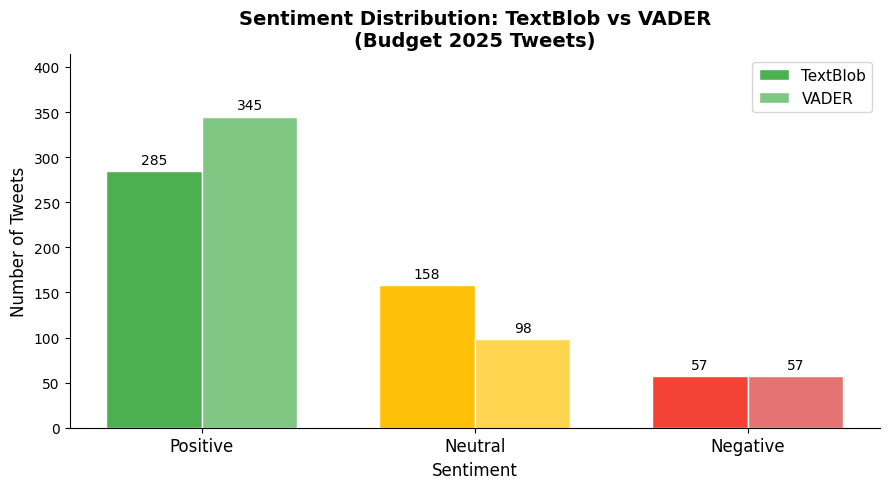

✅ Saved: plot1_sentiment_distribution.png


In [83]:
#  Plot 1: Sentiment Distribution – side-by-side bar chart
labels    = ['Positive', 'Neutral', 'Negative']
tb_counts = [df['textblob_label'].value_counts().get(l, 0) for l in labels]
vd_counts = [df['vader_label'].value_counts().get(l, 0)    for l in labels]

x = np.arange(len(labels))
width = 0.35
colors_tb = ['#4CAF50', '#FFC107', '#F44336']
colors_vd = ['#81C784', '#FFD54F', '#E57373']

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, tb_counts, width, label='TextBlob', color=colors_tb, edgecolor='white')
bars2 = ax.bar(x + width/2, vd_counts, width, label='VADER',    color=colors_vd, edgecolor='white')

ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Sentiment Distribution: TextBlob vs VADER\n(Budget 2025 Tweets)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=11)
ax.bar_label(bars1, padding=3, fontsize=10)
ax.bar_label(bars2, padding=3, fontsize=10)
ax.set_ylim(0, max(max(tb_counts), max(vd_counts)) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot1_sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Saved: plot1_sentiment_distribution.png")

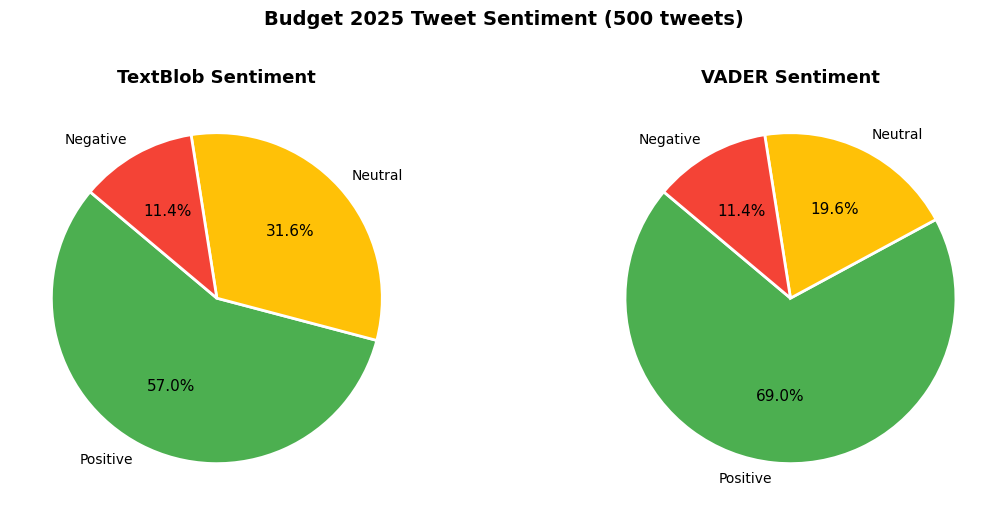

✅ Saved: plot2_pie_charts.png


In [84]:
#  Plot 2: Pie charts (VADER)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pie_colors = ['#4CAF50', '#FFC107', '#F44336']

for ax, col, title in zip(axes,
                           ['textblob_label', 'vader_label'],
                           ['TextBlob Sentiment', 'VADER Sentiment']):
    counts = df[col].value_counts().reindex(labels, fill_value=0)
    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%',
        colors=pie_colors, startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    for at in autotexts:
        at.set_fontsize(11)
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle('Budget 2025 Tweet Sentiment (500 tweets)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot2_pie_charts.png', dpi=150)
plt.show()
print("✅ Saved: plot2_pie_charts.png")

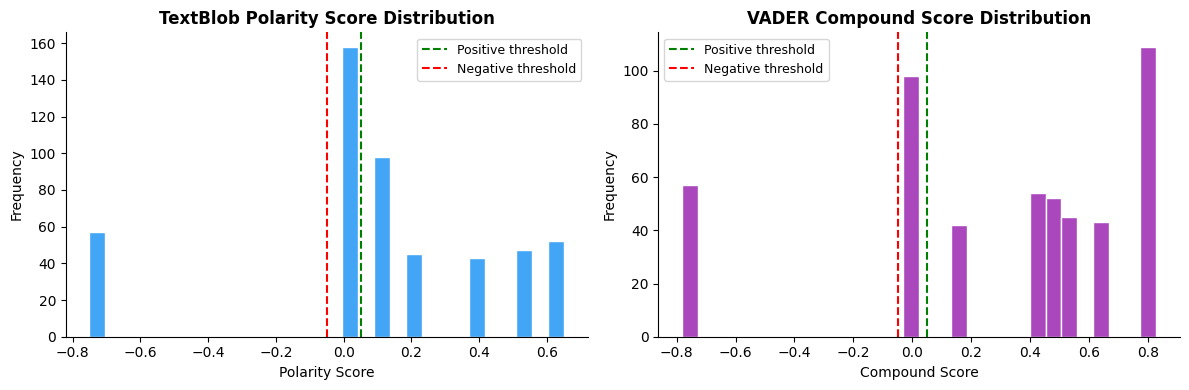

✅ Saved: plot3_score_distributions.png


In [85]:
# Plot 3: Score distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['textblob_score'], bins=30, color='#42A5F5', edgecolor='white')
axes[0].axvline(0.05,  color='green',  linestyle='--', label='Positive threshold')
axes[0].axvline(-0.05, color='red',    linestyle='--', label='Negative threshold')
axes[0].set_title('TextBlob Polarity Score Distribution', fontweight='bold')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

axes[1].hist(df['vader_score'], bins=30, color='#AB47BC', edgecolor='white')
axes[1].axvline(0.05,  color='green', linestyle='--', label='Positive threshold')
axes[1].axvline(-0.05, color='red',   linestyle='--', label='Negative threshold')
axes[1].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[1].set_xlabel('Compound Score')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plot3_score_distributions.png', dpi=150)
plt.show()
print("✅ Saved: plot3_score_distributions.png")

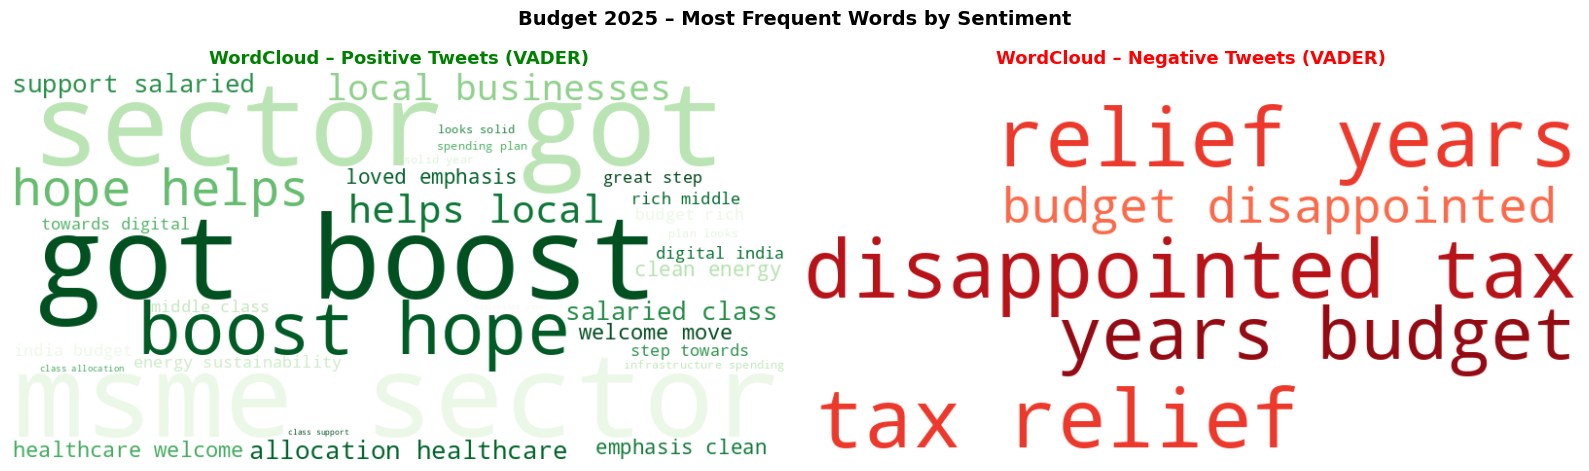

✅ Saved: plot4_wordclouds.png


In [86]:
#  Plot 4: WordClouds for Positive & Negative tweets (VADER)
positive_text = " ".join(df[df['vader_label'] == 'Positive']['clean_text_no_stop'])
negative_text = " ".join(df[df['vader_label'] == 'Negative']['clean_text_no_stop'])

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=80).generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds',   max_words=80).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('WordCloud – Positive Tweets (VADER)', fontsize=13, fontweight='bold', color='green')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('WordCloud – Negative Tweets (VADER)', fontsize=13, fontweight='bold', color='red')
axes[1].axis('off')

plt.suptitle('Budget 2025 – Most Frequent Words by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_wordclouds.png', dpi=150)
plt.show()
print("✅ Saved: plot4_wordclouds.png")

In [87]:
#  Top 20 words per sentiment class (VADER)
for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = df[df['vader_label'] == sentiment]['clean_text_no_stop']
    all_words = " ".join(subset).split()
    top20 = Counter(all_words).most_common(20)
    print(f"\n🔹 Top 20 words in {sentiment} tweets (VADER):")
    print(", ".join([f"{w}({c})" for w, c in top20]))


🔹 Top 20 words in Positive tweets (VADER):
class(99), budget(88), msme(62), sector(62), got(62), boost(62), hope(62), helps(62), local(62), businesses(62), support(54), salaried(54), allocation(52), healthcare(52), welcome(52), move(52), loved(47), emphasis(47), clean(47), energy(47)

🔹 Top 20 words in Negative tweets (VADER):
disappointed(57), tax(57), relief(57), years(57), budget(57)

🔹 Top 20 words in Neutral tweets (VADER):
much(98), budget(51), finally(51), addresses(51), education(51), sector(51), needed(51), focus(47), startups(47), enough(47), agriculture(47)


In [88]:
#  Misclassification examples (models disagree)
disagreements = df[~df['models_agree']].copy()
print(f"Tweets where TextBlob and VADER disagree: {len(disagreements)} / {len(df)}")
print()
print(disagreements[['Content', 'textblob_label', 'vader_label']].head(10).to_string(index=False))

Tweets where TextBlob and VADER disagree: 256 / 500

                                                         Content textblob_label vader_label
         Too much focus on startups, not enough for agriculture.       Positive     Neutral
         Too much focus on startups, not enough for agriculture.       Positive     Neutral
        MSME sector got a boost. Hope it helps local businesses.        Neutral    Positive
                    Where is the support for the salaried class?        Neutral    Positive
        MSME sector got a boost. Hope it helps local businesses.        Neutral    Positive
                    Where is the support for the salaried class?        Neutral    Positive
         The infrastructure spending plan looks solid this year.        Neutral    Positive
Budget 2025 finally addresses the education sector. Much needed!       Positive     Neutral
Budget 2025 finally addresses the education sector. Much needed!       Positive     Neutral
Budget 2025 finally address

In [89]:
#  Final insights summary
total = len(df)
tb_pos = (df['textblob_label'] == 'Positive').sum()
tb_neg = (df['textblob_label'] == 'Negative').sum()
vd_pos = (df['vader_label'] == 'Positive').sum()
vd_neg = (df['vader_label'] == 'Negative').sum()

print("   KEY INSIGHTS – Budget 2025 Tweet Analysis  ")
print()
print(f"Total tweets analysed : {total}")
print()
print(f"TextBlob → Positive: {tb_pos/total:.1%} | Negative: {tb_neg/total:.1%}")
print(f"VADER    → Positive: {vd_pos/total:.1%} | Negative: {vd_neg/total:.1%}")
print()
print(f"Model agreement rate  : {df['models_agree'].mean():.1%}")
print(f"Disagreement count    : {(~df['models_agree']).sum()}")
print()
print("Reflections:")
print("- VADER tends to be better for short, informal social media text.")
print("- TextBlob handles formal/grammatical language better.")
print("- Both tools may miss sarcasm and context-specific political language.")
print("- High neutral counts indicate many tweets are factual/descriptive.")

   KEY INSIGHTS – Budget 2025 Tweet Analysis  

Total tweets analysed : 500

TextBlob → Positive: 57.0% | Negative: 11.4%
VADER    → Positive: 69.0% | Negative: 11.4%

Model agreement rate  : 48.8%
Disagreement count    : 256

Reflections:
- VADER tends to be better for short, informal social media text.
- TextBlob handles formal/grammatical language better.
- Both tools may miss sarcasm and context-specific political language.
- High neutral counts indicate many tweets are factual/descriptive.
